# Bài thực hành 2: Hồi quy logistic

**Sinh viên:** Nguyễn Thành Phong · **Học phần:** Học máy ứng dụng · **Giảng viên:** ThS. Nguyễn Thái Anh

Dữ liệu: `data/sinh_vien.csv`, 120 sinh viên, 3 cột `gio_on`, `diem_giua_ky`, `qua_mon` (1 = qua, 0 = rớt).

In [1]:
# Chuẩn bị dữ liệu: chạy local thì đọc thẳng, trên Colab thì tải tệp lên
import os
DATA = "data/sinh_vien.csv"
if not os.path.exists(DATA):
    from google.colab import files
    files.upload()                         # chon tep sinh_vien.csv
    os.makedirs("data", exist_ok=True)
    os.replace("sinh_vien.csv", DATA)
print("Co sinh_vien.csv chua?", os.path.exists(DATA))

Co sinh_vien.csv chua? True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)

## 1. Đọc dữ liệu (`c1_doc_du_lieu.py`)

In [3]:
df = pd.read_csv(DATA)

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()
print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()
print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


### Vì sao không dùng lại đường thẳng của bài 1 (Hình 1)

Duong thang nhan gia tri tu -0.103 toi 1.250
So ban bi gan gia tri ngoai [0, 1]: 25


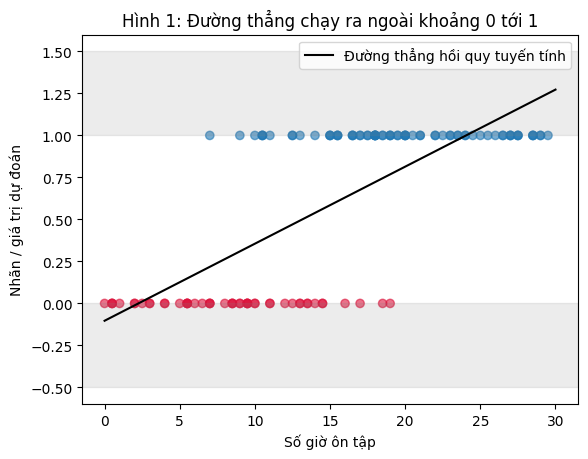

In [4]:
X, y = df[["gio_on"]], df["qua_mon"]
duong_thang = LinearRegression().fit(X, y)
du_doan = duong_thang.predict(X)
print(f"Duong thang nhan gia tri tu {du_doan.min():.3f} toi {du_doan.max():.3f}")
print("So ban bi gan gia tri ngoai [0, 1]:", ((du_doan < 0) | (du_doan > 1)).sum())

xs = pd.DataFrame({"gio_on": np.linspace(0, 30, 100)})
plt.scatter(df["gio_on"], y, c=y.map({0: "crimson", 1: "tab:blue"}), alpha=.6)
plt.plot(xs["gio_on"], duong_thang.predict(xs), "k", label="Đường thẳng hồi quy tuyến tính")
plt.axhspan(1, 1.5, color="grey", alpha=.15); plt.axhspan(-0.5, 0, color="grey", alpha=.15)
plt.xlabel("Số giờ ôn tập"); plt.ylabel("Nhãn / giá trị dự đoán")
plt.title("Hình 1: Đường thẳng chạy ra ngoài khoảng 0 tới 1"); plt.legend(); plt.show()

## 2. Hàm sigmoid (`c2_sigmoid.py`)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [5]:
def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))

print("Bang gia tri cua ham sigmoid")
print("  z   sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}   {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    print(f"  z = {z}: {sigmoid(-z):.6f} va {1 - sigmoid(z):.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print("  So gio on   z = w*x + b   Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"  {gio:5.1f}       {z:6.2f}        {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
  z   sigmoid(z)
 -6   0.0025
 -4   0.0180
 -2   0.1192
 -1   0.2689
  0   0.5000
  1   0.7311
  2   0.8808
  4   0.9820
  6   0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z = 1.0: 0.268941 va 0.268941
  z = 2.5: 0.075858 va 0.075858
  z = 3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
  So gio on   z = w*x + b   Xac suat qua mon
    5.0        -3.00        0.0474
   10.0        -1.00        0.2689
   12.5         0.00        0.5000
   15.0         1.00        0.7311
   20.0         3.00        0.9526
   25.0         5.00        0.9933


## 3. Khớp mô hình bằng scikit-learn (`c3_khop_mo_hinh.py`)

In [6]:
X = df[["gio_on"]]        # X hai ngoac vuong, y mot ngoac
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])
print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"So gio on ung voi xac suat 0.5: {-b / w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)
print("Du doan cho nam ban moi:")
print("  So gio on   Xac suat qua   Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"  {gio:5.1f}       {p:.4f}         {n}")

He so goc  w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
  So gio on   Xac suat qua   Nhan mo hinh dua ra
    5.0       0.0431         0
   10.0       0.2429         0
   13.0       0.5104         1
   20.0       0.9422         1
   28.0       0.9974         1


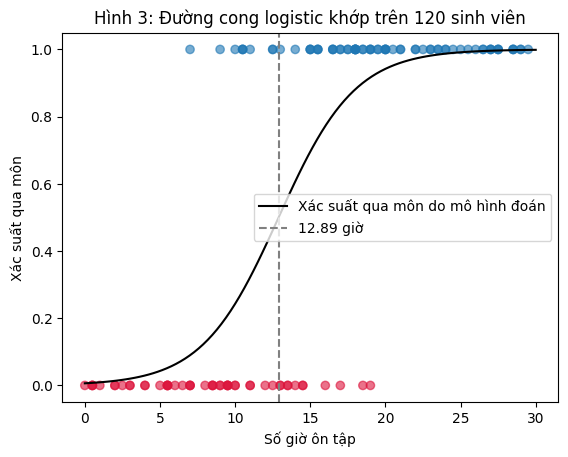

In [7]:
# Hình 3: đường cong logistic
plt.scatter(df["gio_on"], y, c=y.map({0: "crimson", 1: "tab:blue"}), alpha=.6)
plt.plot(xs["gio_on"], mo_hinh.predict_proba(xs)[:, 1], "k", label="Xác suất qua môn do mô hình đoán")
plt.axvline(-b / w, ls="--", c="grey", label=f"{-b / w:.2f} giờ")
plt.xlabel("Số giờ ôn tập"); plt.ylabel("Xác suất qua môn")
plt.title("Hình 3: Đường cong logistic khớp trên 120 sinh viên"); plt.legend(); plt.show()

## 4. Chấm điểm mô hình (`c4_danh_gia.py`)

In [8]:
# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
print("So sinh vien de hoc     :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d}  doan rot, that su rot")
print(f"  FP = {fp:2d}  doan qua, that ra rot")
print(f"  FN = {fn:2d}  doan rot, that ra qua")
print(f"  TP = {tp:2d}  doan qua, that su qua")
print()
print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")

So sinh vien de hoc     : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
  TN =  9  doan rot, that su rot
  FP =  3  doan qua, that ra rot
  FN =  1  doan rot, that ra qua
  TP = 17  doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947


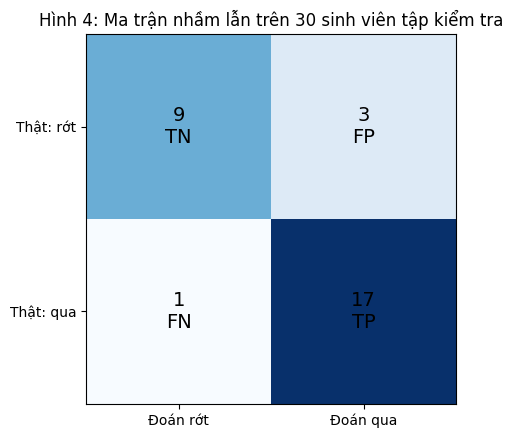

In [9]:
# Hình 4: ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
nhan_o = [["TN", "FP"], ["FN", "TP"]]
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]}\n{nhan_o[i][j]}", ha="center", va="center", fontsize=14)
plt.xticks([0, 1], ["Đoán rớt", "Đoán qua"]); plt.yticks([0, 1], ["Thật: rớt", "Thật: qua"])
plt.title("Hình 4: Ma trận nhầm lẫn trên 30 sinh viên tập kiểm tra"); plt.show()

## 5. Ngưỡng quyết định (`c5_doi_nguong.py`)

In [10]:
# predict_proba trả về hai cột, cột 0 cho lớp 0 và cột 1 cho lớp 1
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong   So ban bi doan la qua   Precision   Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_nguong = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_nguong, zero_division=1)
    rec = recall_score(y_test, y_nguong, zero_division=0)
    print(f"  {nguong:.1f}          {y_nguong.sum():3d}               {pre:.4f}     {rec:.4f}")

Nguong   So ban bi doan la qua   Precision   Recall
  0.2           24               0.7500     1.0000
  0.3           20               0.8500     0.9444
  0.4           20               0.8500     0.9444
  0.5           20               0.8500     0.9444
  0.6           16               1.0000     0.8889
  0.7           15               1.0000     0.8333
  0.8           13               1.0000     0.7222


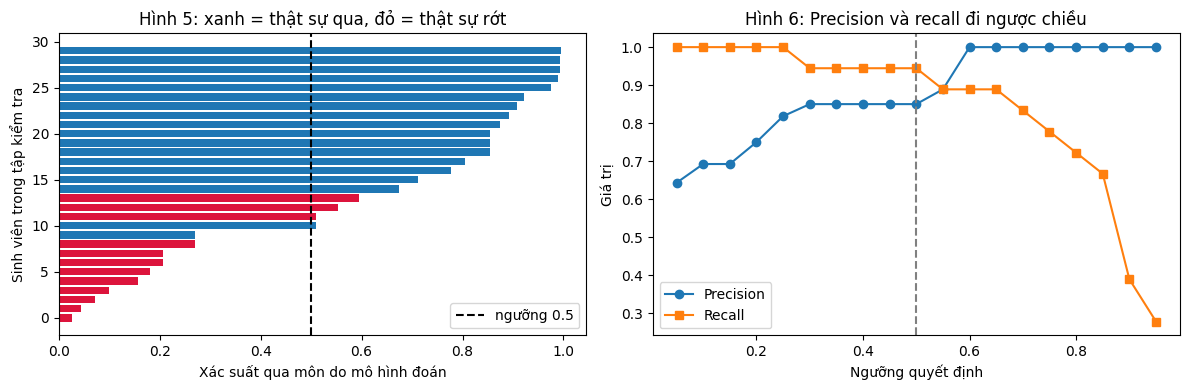

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Hình 5: xác suất từng bạn trong tập kiểm tra, xếp tăng dần
thu_tu = np.argsort(p)
mau = np.where(y_test.to_numpy()[thu_tu] == 1, "tab:blue", "crimson")
ax[0].barh(range(len(p)), p[thu_tu], color=mau)
ax[0].axvline(0.5, c="k", ls="--", label="ngưỡng 0.5")
ax[0].set_xlabel("Xác suất qua môn do mô hình đoán"); ax[0].set_ylabel("Sinh viên trong tập kiểm tra")
ax[0].set_title("Hình 5: xanh = thật sự qua, đỏ = thật sự rớt"); ax[0].legend()

# Hình 6: precision và recall theo ngưỡng
dai_nguong = np.arange(0.05, 1.0, 0.05)
ds_pre = [precision_score(y_test, (p >= t).astype(int), zero_division=1) for t in dai_nguong]
ds_rec = [recall_score(y_test, (p >= t).astype(int), zero_division=0) for t in dai_nguong]
ax[1].plot(dai_nguong, ds_pre, "o-", label="Precision")
ax[1].plot(dai_nguong, ds_rec, "s-", label="Recall")
ax[1].axvline(0.5, c="grey", ls="--")
ax[1].set_xlabel("Ngưỡng quyết định"); ax[1].set_ylabel("Giá trị")
ax[1].set_title("Hình 6: Precision và recall đi ngược chiều"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Thêm biến đầu vào thứ hai (`c6_hai_bien.py`)

In [12]:
# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
for ten, cot in [("Mot bien", ["gio_on"]),
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    Xi = df[cot]
    a, b_, c, d = train_test_split(Xi, y, test_size=0.25, random_state=17, stratify=y)
    m = LogisticRegression().fit(a, c)
    print(f"{ten}: accuracy tren tap kiem tra = {accuracy_score(d, m.predict(b_)):.4f}")
print()

X2 = df[["gio_on", "diem_giua_ky"]]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.25, random_state=17, stratify=y
)
m2 = LogisticRegression().fit(X2_train, y2_train)
print("He so cua tung bien:")
for ten_cot, he_so in zip(X2.columns, m2.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {m2.intercept_[0]:+.4f}")

Mot bien: accuracy tren tap kiem tra = 0.8667


Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811


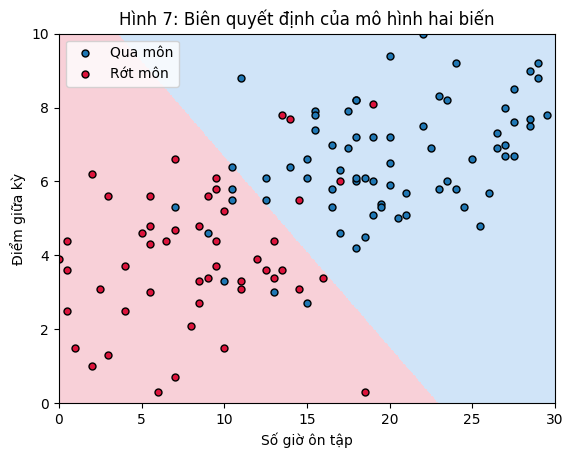

In [13]:
# Hình 7: biên quyết định của mô hình hai biến
gx, gy = np.meshgrid(np.linspace(0, 30, 300), np.linspace(0, 10, 300))
luoi = pd.DataFrame({"gio_on": gx.ravel(), "diem_giua_ky": gy.ravel()})
vung = m2.predict(luoi).reshape(gx.shape)
plt.contourf(gx, gy, vung, levels=[-0.5, 0.5, 1.5], colors=["#f8d0d8", "#d0e4f8"])
for nhan_, mau_, ten_ in [(1, "tab:blue", "Qua môn"), (0, "crimson", "Rớt môn")]:
    nhom = df[df["qua_mon"] == nhan_]
    plt.scatter(nhom["gio_on"], nhom["diem_giua_ky"], c=mau_, label=ten_, edgecolor="k", s=25)
plt.xlabel("Số giờ ôn tập"); plt.ylabel("Điểm giữa kỳ")
plt.title("Hình 7: Biên quyết định của mô hình hai biến"); plt.legend(); plt.show()

---
# Bài tập

## Bài tập 1: Thống kê theo nhóm
Số bạn có điểm giữa kỳ từ 7 trở lên, tỷ lệ qua môn của nhóm đó và của nhóm còn lại.

In [14]:
nhom_cao = df[df["diem_giua_ky"] >= 7]
nhom_con_lai = df[df["diem_giua_ky"] < 7]
print(f"So ban co diem giua ky >= 7      : {len(nhom_cao)}")
print(f"Ty le qua mon nhom >= 7          : {nhom_cao['qua_mon'].mean():.4f}")
print(f"Ty le qua mon nhom con lai (< 7) : {nhom_con_lai['qua_mon'].mean():.4f}")

So ban co diem giua ky >= 7      : 31
Ty le qua mon nhom >= 7          : 0.9032
Ty le qua mon nhom con lai (< 7) : 0.4831


**Nhận xét.** Nhóm có điểm giữa kỳ từ 7 trở lên qua môn 90.32%, gần gấp đôi mức 48.31% của nhóm còn lại.
Vậy điểm giữa kỳ phân biệt được hai nhóm khá rõ. Dù vậy nhóm điểm cao vẫn có 3 trong 31 bạn rớt,
nên chỉ dựa vào điểm giữa kỳ thì chưa đủ.

## Bài tập 2: Vẽ hàm sigmoid
z chạy từ −8 tới 8, thêm đường ngang tại 0.5 và đường dọc tại z = 0, lưu thành `sigmoid.png`.

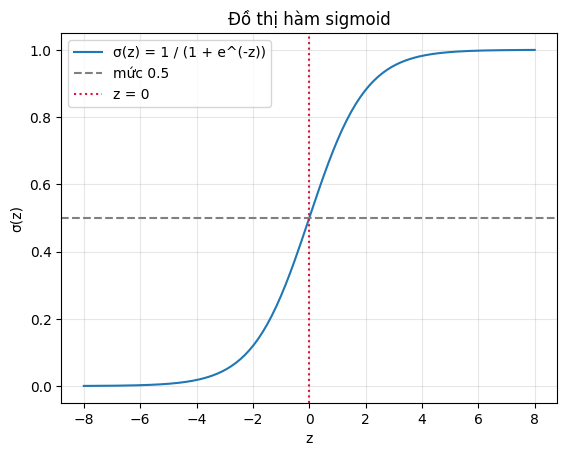

Da luu sigmoid.png


In [15]:
z = np.linspace(-8, 8, 200)
plt.plot(z, sigmoid(z), label="σ(z) = 1 / (1 + e^(-z))")
plt.axhline(0.5, c="grey", ls="--", label="mức 0.5")
plt.axvline(0, c="crimson", ls=":", label="z = 0")
plt.xlabel("z"); plt.ylabel("σ(z)"); plt.title("Đồ thị hàm sigmoid")
plt.legend(); plt.grid(alpha=.3)
plt.savefig("sigmoid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Da luu sigmoid.png")

## Bài tập 3: Dự đoán cho một bạn cụ thể
Khớp lại mô hình một biến trên toàn bộ 120 bạn như mục 3, rồi viết hàm `du_doan(gio)`.

In [16]:
mo_hinh_1 = LogisticRegression().fit(df[["gio_on"]], df["qua_mon"])
W1 = float(mo_hinh_1.coef_[0][0])
B1 = float(mo_hinh_1.intercept_[0])

def du_doan(gio, nguong=0.5):
    """In z, xac suat qua mon va nhan theo nguong cho mot so gio on."""
    z = W1 * gio + B1
    xac_suat = sigmoid(z)
    nhan = int(xac_suat >= nguong)
    print(f"  {gio:6.2f} gio   z = {z:+.4f}   xac suat = {xac_suat:.4f}   nhan = {nhan}")

print(f"Mo hinh: w = {W1:.6f}, b = {B1:.6f}, moc 0.5 tai {-B1 / W1:.4f} gio")
for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

Mo hinh: w = 0.392819, b = -5.064890, moc 0.5 tai 12.8937 gio
    3.00 gio   z = -3.8864   xac suat = 0.0201   nhan = 0
    8.00 gio   z = -1.9223   xac suat = 0.1276   nhan = 0
   12.89 gio   z = -0.0015   xac suat = 0.4996   nhan = 0
   18.00 gio   z = +2.0059   xac suat = 0.8814   nhan = 1
   26.00 gio   z = +5.1484   xac suat = 0.9942   nhan = 1


**Giải thích.** Xác suất bằng 0.5 khi và chỉ khi z = wx + b = 0, tức x = −b/w = 5.064890 / 0.392819 ≈ 12.8937 giờ.
12.89 giờ gần như trùng mốc đó nên z = −0.0015 ≈ 0, và σ(0) = 0.5, nên xác suất ra 0.4996.
Nó không ra đúng 0.5000 vì 12.89 là số đã làm tròn, nằm dưới mốc thật 0.0037 giờ. Cũng vì vậy mà nhãn theo ngưỡng 0.5
lại là 0: chỉ cần lệch một chút về phía dưới mốc là mô hình nghiêng về rớt, dù thực chất nó đang phân vân năm mươi năm mươi.

## Bài tập 4: Tự tính bốn thước đo
Dùng lại đoạn chia dữ liệu của `c4_danh_gia.py`, bỏ các hàm `accuracy_score`, `precision_score`,
`recall_score`, `f1_score`, chỉ tính từ TP, TN, FP, FN.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["gio_on"]], df["qua_mon"], test_size=0.25, random_state=17, stratify=df["qua_mon"]
)
mo_hinh_4 = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh_4.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")
print()

n = tp + tn + fp + fn
accuracy = (tp + tn) / n
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

# Số thư viện in ra trong tài liệu, mục 5.2
tai_lieu = {"Accuracy": 0.8667, "Precision": 0.8500, "Recall": 0.9444, "F1": 0.8947}
tu_tinh = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}
print("Thuoc do    Tu tinh   Tai lieu   Khop?")
for ten in tu_tinh:
    print(f"{ten:10s}  {tu_tinh[ten]:.4f}    {tai_lieu[ten]:.4f}     {round(tu_tinh[ten], 4) == tai_lieu[ten]}")

TP = 17, TN = 9, FP = 3, FN = 1

Thuoc do    Tu tinh   Tai lieu   Khop?
Accuracy    0.8667    0.8667     True
Precision   0.8500    0.8500     True
Recall      0.9444    0.9444     True
F1          0.8947    0.8947     True


**Nhận xét.** Bốn con số tự tính khớp với thư viện tới chữ số thứ tư.
- Accuracy = (17 + 9) / 30: mô hình đoán đúng 26 trên 30 bạn.
- Precision = 17 / (17 + 3): trong 20 bạn mô hình nói sẽ qua thì 17 bạn qua thật. Mẫu số là *những gì mô hình nói*.
- Recall = 17 / (17 + 1): trong 18 bạn thật sự qua, mô hình tìm ra 17. Mẫu số là *những gì có thật*.
- F1 là trung bình điều hòa của precision và recall, nên nó bị kéo về phía số nhỏ hơn (0.8500), không phải trung bình cộng 0.8972.

## Bài tập 5: Dò ngưỡng tốt nhất theo F1
Ngưỡng chạy từ 0.05 tới 0.95, bước 0.05.

In [18]:
p = mo_hinh_4.predict_proba(X_test)[:, 1]
cac_nguong = np.arange(0.05, 1.0, 0.05)
ds_f1 = []
print("Nguong    F1")
for nguong in cac_nguong:
    f1_t = f1_score(y_test, (p >= nguong).astype(int), zero_division=0)
    ds_f1.append(f1_t)
    print(f" {nguong:.2f}   {f1_t:.4f}")

vi_tri = int(np.argmax(ds_f1))
print()
print(f"Nguong cho F1 cao nhat: {cac_nguong[vi_tri]:.2f} (F1 = {ds_f1[vi_tri]:.4f})")
print(f"F1 tai nguong 0.50   : {ds_f1[9]:.4f}")

Nguong    F1
 0.05   0.7826
 0.10   0.8182
 0.15   0.8182
 0.20   0.8571
 0.25   0.9000
 0.30   0.8947
 0.35   0.8947
 0.40   0.8947
 0.45   0.8947
 0.50   0.8947
 0.55   0.8889
 0.60   0.9412
 0.65   0.9412
 0.70   0.9091
 0.75   0.8750
 0.80   0.8387
 0.85   0.8000
 0.90   0.5600
 0.95   0.4348

Nguong cho F1 cao nhat: 0.60 (F1 = 0.9412)
F1 tai nguong 0.50   : 0.8947


**Nhận xét.** Ngưỡng tốt nhất theo F1 là 0.60 (F1 = 0.9412, ngưỡng 0.65 cũng cho F1 bằng đúng như vậy),
không phải 0.5 (F1 = 0.8947). 0.5 chỉ là ngưỡng mặc định chứ không tối ưu sẵn cho thước đo nào. Nhưng tập
kiểm tra chỉ có 30 bạn, nâng ngưỡng lên 0.6 chỉ đổi được vài bạn, nên chọn ngưỡng trên chính tập kiểm tra
dễ bị khớp theo may rủi.

## Bài tập 6: Đổi lớp dương rồi chấm lại
Lấy lớp dương là **rớt môn** (lớp 0) bằng `pos_label=0`.

In [19]:
y_pred = mo_hinh_4.predict(X_test)
print("Lop duong       Precision   Recall")
for lop, ten in [(1, "qua mon (1)"), (0, "rot mon (0)")]:
    pre = precision_score(y_test, y_pred, pos_label=lop)
    rec = recall_score(y_test, y_pred, pos_label=lop)
    print(f"{ten:14s}   {pre:.4f}     {rec:.4f}")
print()
print(f"Lop 0: precision = TN / (TN + FN) = {tn} / ({tn} + {fn}) = {tn / (tn + fn):.4f}")
print(f"       recall    = TN / (TN + FP) = {tn} / ({tn} + {fp}) = {tn / (tn + fp):.4f}")

Lop duong       Precision   Recall
qua mon (1)      0.8500     0.9444
rot mon (0)      0.9000     0.7500

Lop 0: precision = TN / (TN + FN) = 9 / (9 + 1) = 0.9000
       recall    = TN / (TN + FP) = 9 / (9 + 3) = 0.7500


**Giải thích.** Mô hình và 30 dự đoán không đổi, chỉ đổi câu hỏi. Khi lớp dương là rớt môn, vai trò bốn ô hoán đổi:
TN trở thành "TP mới", FN trở thành "FP mới", FP trở thành "FN mới".

- Lớp 1 (qua): precision 0.8500, recall 0.9444. Mô hình bắt gần hết bạn qua môn.
- Lớp 0 (rớt): precision 0.9000 = 9/10, recall 0.7500 = 9/12. Trong 12 bạn thật sự rớt, mô hình bỏ sót 3 bạn
  (chính là 3 ca FP khi nhìn từ phía lớp 1).

Với bài toán cảnh báo sinh viên sắp rớt thì recall của lớp 0 mới là con số quan trọng: 0.75 nghĩa là cứ 4 bạn
cần nhắc nhở thì bỏ sót 1. Nhìn riêng recall 0.9444 của lớp qua môn sẽ đánh giá mô hình quá lạc quan, vì vậy
khi báo cáo phải luôn nói rõ đang tính cho lớp nào.